In [2]:
# Download and extract the dataset
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces --unzip -p ./real_vs_fake_faces

# Verify that the dataset is downloaded
!ls ./real_vs_fake_faces

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.74G/3.75G [00:55<00:00, 158MB/s]
100% 3.75G/3.75G [00:55<00:00, 72.1MB/s]
real_vs_fake  test.csv	train.csv  valid.csv


In [3]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn import metrics
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from sklearn.metrics import classification_report
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import load_img
from sklearn.metrics import accuracy_score, roc_curve, auc
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [4]:
# Data Preparation
datapath = '/content/real_vs_fake_faces/real_vs_fake/real-vs-fake/'
image_gen = ImageDataGenerator(rescale=1./255.)
batch_size = 64
train_flow = image_gen.flow_from_directory(
    datapath + 'train/', target_size=(224, 224), batch_size=batch_size, class_mode='binary'
)
valid_flow = image_gen.flow_from_directory(
    datapath + 'valid/', target_size=(224, 224), batch_size=batch_size, class_mode='binary'
)
test_flow = image_gen.flow_from_directory(
    datapath + 'test/', target_size=(224, 224), batch_size=1, shuffle=False, class_mode='binary'
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [5]:
#plotting real and fake faces from dataset
def plot_img(path, set_):
    dir_ = os.path.join(path, 'train', set_)
    k = np.random.randint(20000)
    fig, ax = plt.subplots(3,3, figsize=(8,8))
    for j in range(3):
        for i in range(3):
            img = load_img(os.path.join(dir_, os.listdir(os.path.join(dir_))[k]))
            ax[j,i].imshow(img)
            ax[j,i].set_title("")
            ax[j,i].axis('off')
            k = np.random.randint(20000)
    plt.suptitle(set_ + ' faces from train dataset')
    return plt

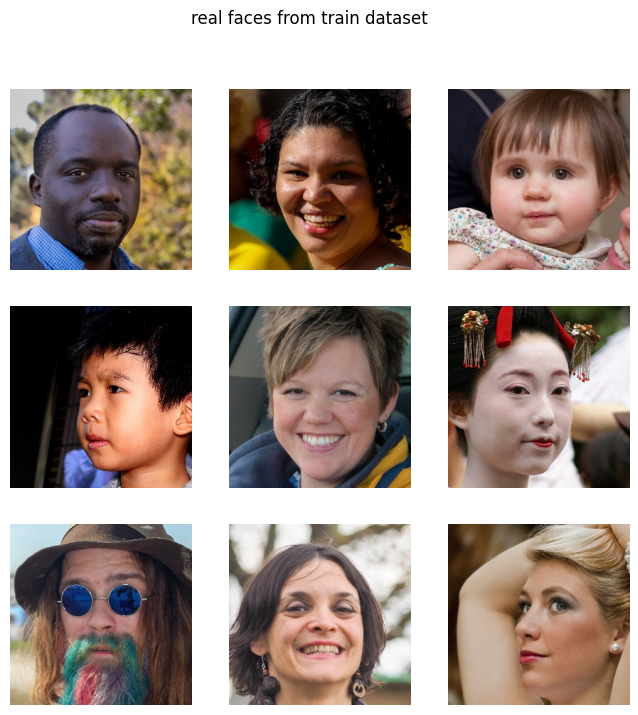

In [6]:
plot_img(datapath, 'real').show()

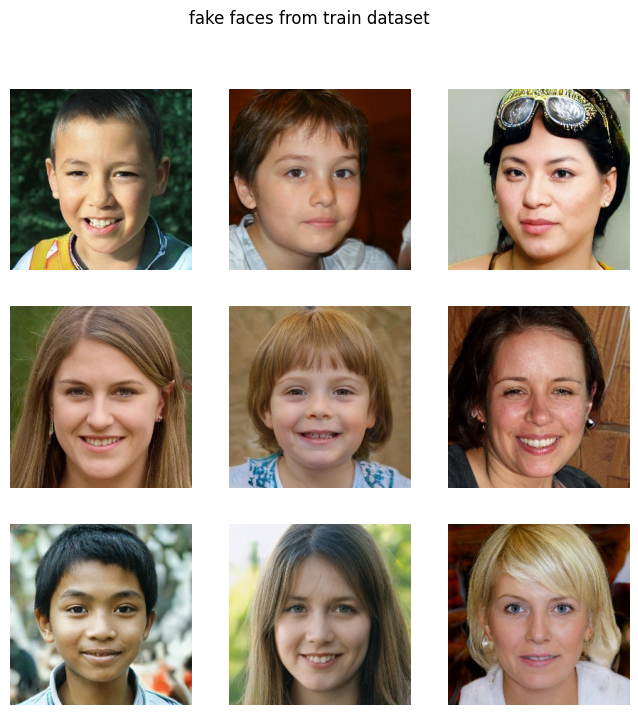

In [7]:
plot_img(datapath, 'fake').show()

In [8]:
# Base CNN Model Architecture
def create_cnn_model(input_shape):
    model = Sequential()

    # Initial Batch Normalization to normalize input
    model.add(layers.BatchNormalization(input_shape=input_shape))

    # First Convolutional Block: Conv2D -> MaxPooling -> BatchNorm
    model.add(layers.Conv2D(filters=16, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=2))
    model.add(layers.BatchNormalization())

    # Second Convolutional Block: Conv2D -> MaxPooling -> BatchNorm
    model.add(layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=2))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.1)) # Dropout for regularization

    # Third Convolutional Block: Conv2D -> MaxPooling -> BatchNorm
    model.add(layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=2))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.1))

    # Fourth Convolutional Block: Conv2D -> MaxPooling -> BatchNorm
    model.add(layers.Conv2D(filters=128, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=2))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.1))

    # Fifth Convolutional Block: Conv2D -> MaxPooling -> BatchNorm
    model.add(layers.Conv2D(filters=256, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=2))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.1))

    # Sixth Convolutional Block: Conv2D -> MaxPooling -> BatchNorm
    model.add(layers.Conv2D(filters=512, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=2))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.1))

    # Final Convolutional Block: Conv2D -> MaxPooling -> BatchNorm
    model.add(layers.Conv2D(filters=1024, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=2))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.1))

    # Flatten the feature maps into a vector for classification
    model.add(layers.Flatten())

    # Output layer for binary classification with sigmoid activation
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

In [9]:
# Create CNN Model
cnn_model = create_cnn_model((224, 224, 3))
cnn_model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0001), metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/normalization/batch_normalization.py:143: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
# Train CNN Model with Model Checkpointing
history=cnn_model.fit(
    train_flow,
    epochs=6,
    validation_data=valid_flow,
    callbacks=[ModelCheckpoint(
        "saved-cnn-model.keras",
        monitor='val_accuracy',
        save_best_only=True,
        mode='max')], # Maximize validation accuracy during training
)

Epoch 1/6


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 352s 210ms/step - accuracy: 0.7056 - loss: 0.6136 - val_accuracy: 0.6684 - val_loss: 0.7384
Epoch 2/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 391s 227ms/step - accuracy: 0.8337 - loss: 0.3720 - val_accuracy: 0.7885 - val_loss: 0.5054
Epoch 3/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 295s 188ms/step - accuracy: 0.8956 - loss: 0.2485 - val_accuracy: 0.7977 - val_loss: 0.5262
Epoch 4/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 299s 190ms/step - accuracy: 0.9301 - loss: 0.1735 - val_accuracy: 0.8932 - val_loss: 0.2636
Epoch 5/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 318s 188ms/step - accuracy: 0.9496 - loss: 0.1271 - val_accuracy: 0.9420 - val_loss: 0.1457
Epoch 6/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 328s 192ms/step - accuracy: 0.9626 - loss: 0.0953 - val_accuracy: 0.9485 - val_loss: 0.1325


In [11]:
# Load the saved models
from keras.models import load_model

model_path = "/content/saved-cnn-model.keras"
# best_cnn_model = load_model(model_path)


# After training, convert the `.keras` model to `.h5` format
cnn_model = load_model(model_path)
cnn_model.save("CNN.h5")  # Save explicitly as .h5

In [12]:
from keras.models import load_model

model = load_model('/content/CNN.h5')

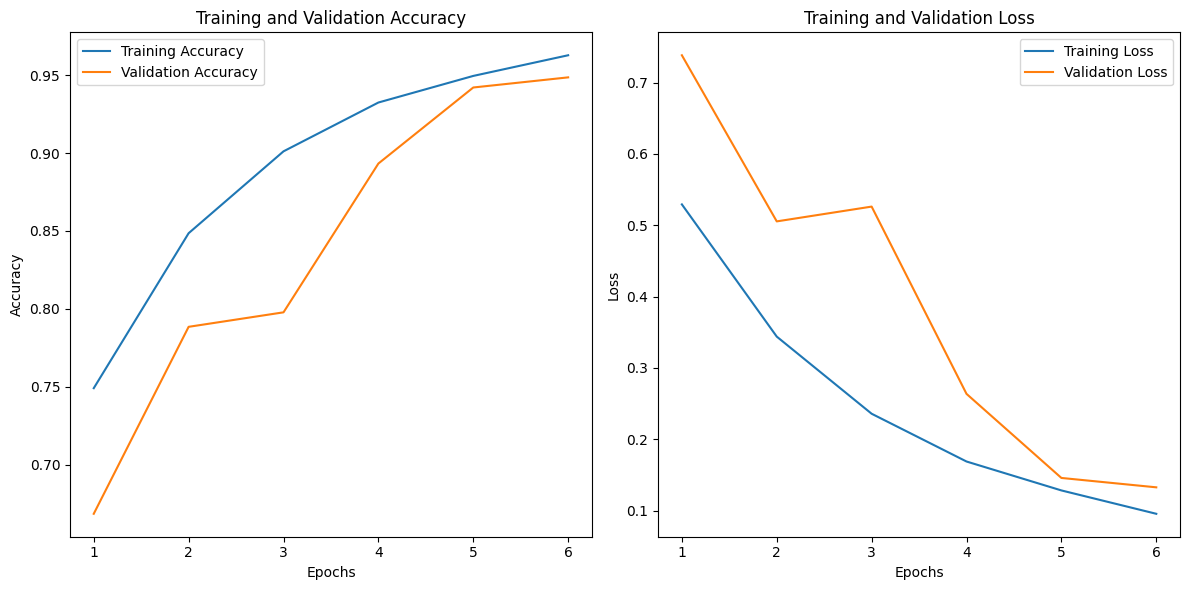

In [ ]:
# Function to Plot Training History
def plot_training_history(history):
    epochs = range(1, len(history.history["loss"]) + 1)

    # Plot Training and Validation Accuracy
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history["accuracy"], label="Training Accuracy")
    plt.plot(epochs, history.history["val_accuracy"], label="Validation Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # Plot Training and Validation Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history["loss"], label="Training Loss")
    plt.plot(epochs, history.history["val_loss"], label="Validation Loss")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot Training History
plot_training_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


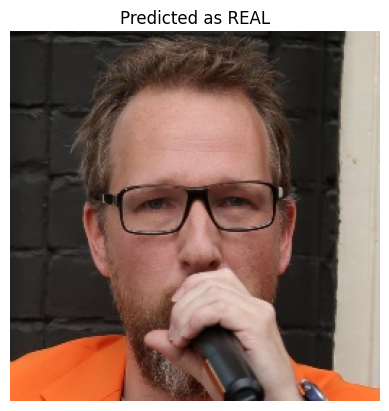

In [14]:
# Real-Time Prediction with Live Photo
live_photo_path = "/content/real_vs_fake_faces/real_vs_fake/real-vs-fake/valid/real/00005.jpg"
live_photo = load_img(live_photo_path, target_size=(224, 224))
live_photo = img_to_array(live_photo) / 255.0
live_photo = np.expand_dims(live_photo, axis=0)

# Predict on Live Photo
live_prediction = model.predict(live_photo)

# Display Prediction Result
plt.imshow(mpimg.imread(live_photo_path))
plt.axis('off')
if live_prediction[0][0] < 0.5:
    prediction = "FAKE"
else:
    prediction = "REAL"

plt.title(f"Predicted as {prediction}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.10/dist-packages/matplotlib/pyplot.py'>

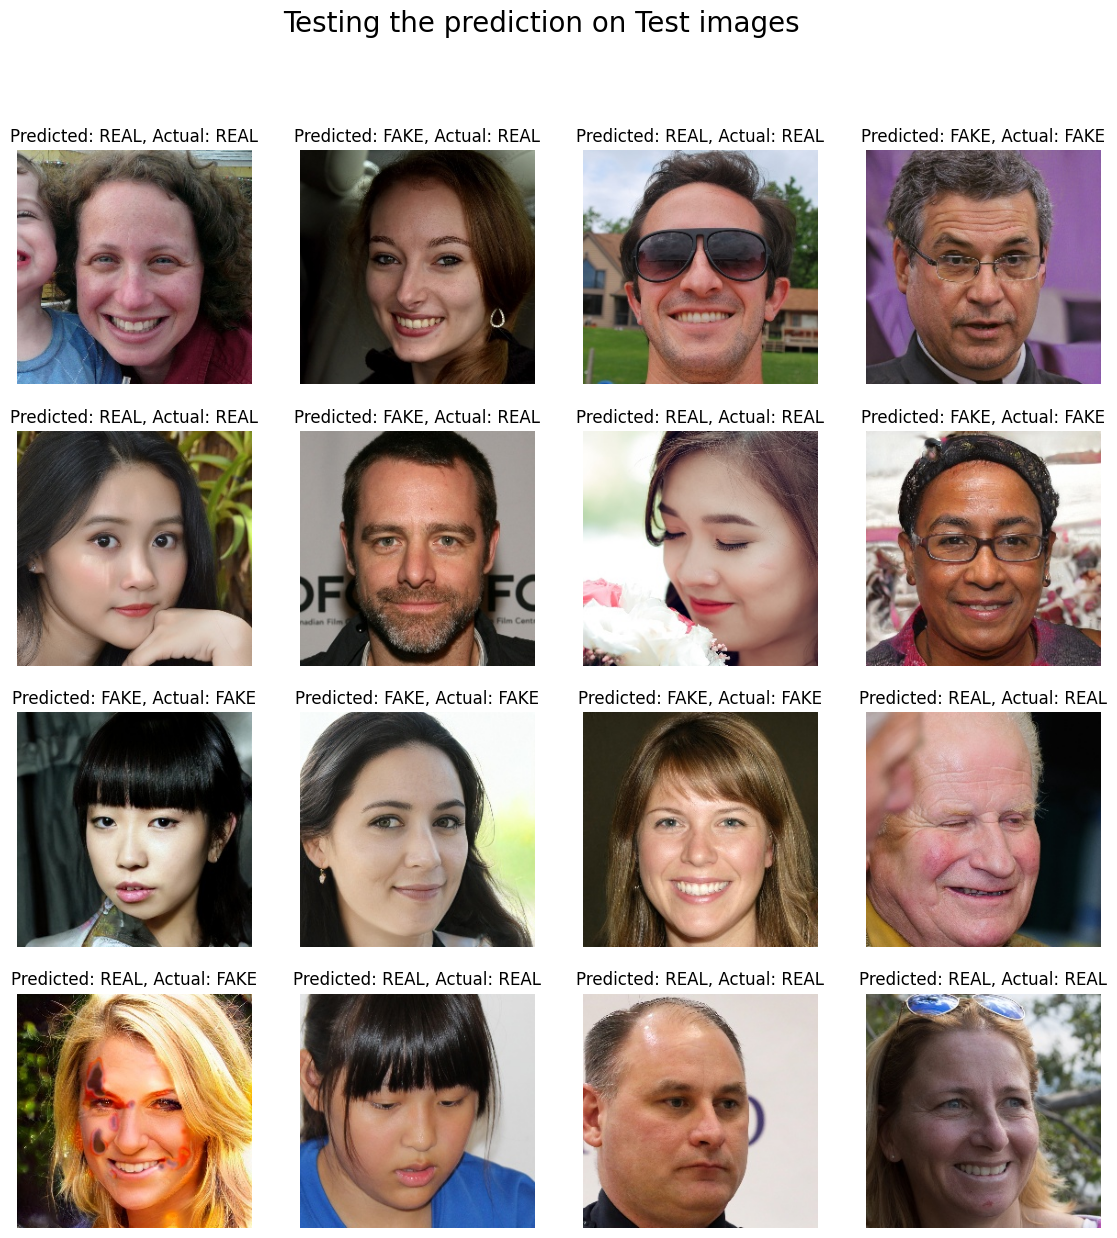

In [15]:
# Display a grid of test images with their predicted and actual classes
def predict_img_class():
    k = np.random.randint(20000)
    gridx = 4
    gridy = 4
    fig, ax = plt.subplots(gridx,gridy, figsize=(14,14))

    for j in range(gridx):
        for i in range(gridy):
            # Determine the actual class of the image (FAKE or REAL)
            if test_flow.classes[k] == 0:
                actual = "FAKE"
            else:
                actual = "REAL"

            # Predict the class using the model
            if model.predict(test_flow[k][0])[0][0]<0.5:
                prediction = "FAKE"
            else:
                prediction = "REAL"

            # Load the image from the dataset path
            datasetpath = test_flow.filenames[k]
            imgpath = datapath+'test/'+datasetpath
            img = load_img(imgpath)

            # Display the image along with the predicted and actual labels
            ax[j,i].imshow(img)
            ax[j,i].set_title(f"Predicted: {prediction}, Actual: {actual}",size = 12)
            ax[j,i].axis('off')
            k = np.random.randint(20000)

    fig.suptitle('Testing the prediction on Test images', size = 20)
    return plt

predict_img_class()